In [ ]:
## libraries

!pip install -q ultralytics

import os
import shutil
from pathlib import Path

import torch
import yaml
from ultralytics import YOLO

In [ ]:
## device information

print("Hardware Information")

if torch.cuda.is_available():
    print("GPU Available")
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)
else:
    print("No GPU detected.")
    print("Go to Runtime → Change runtime type → GPU")

Hardware Information
GPU Available
GPU : Tesla T4
CUDA Version : 12.8


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pathlib import Path

# dataset path in drive
DRIVE_DATASET = Path("/content/drive/MyDrive/FishDetection.v5i.yolov11")

# dataset to Colab SSD
LOCAL_DATASET = Path("/content/FishDetection.v5i.yolov11")

OUTPUT_DIR = Path("/content/drive/MyDrive/FishProjectOutputs")

OUTPUT_DIR.mkdir(exist_ok=True)

print("Drive Dataset :", DRIVE_DATASET)
print("Local Dataset :", LOCAL_DATASET)
print("Output Folder :", OUTPUT_DIR)

Drive Dataset : /content/drive/MyDrive/FishDetection.v5i.yolov11
Local Dataset : /content/FishDetection.v5i.yolov11
Output Folder : /content/drive/MyDrive/FishProjectOutputs


In [ ]:
if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)

print("Copying dataset to local SSD...")

shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

print("Done.")

print("Dataset location:")
print(LOCAL_DATASET)

Copying dataset to local SSD...
Done.
Dataset location:
/content/FishDetection.v5i.yolov11


In [ ]:
# yaml path

yaml_path = LOCAL_DATASET / "data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Dataset Information")

print("Classes :", data["nc"])

print("\nClass Names")

for i, c in enumerate(data["names"]):
    print(f"{i:2d} : {c}")

Dataset Information
Classes : 13

Class Names
 0 : AngelFish
 1 : BlueTang
 2 : ButterflyFish
 3 : ClownFish
 4 : GoldFish
 5 : Gourami
 6 : MorishIdol
 7 : PlatyFish
 8 : RibbonedSweetlips
 9 : ThreeStripedDamselfish
10 : YellowCichlid
11 : YellowTang
12 : ZebraFish


In [ ]:
splits = ["train", "valid", "test"]

print("Dataset Statistics")

for split in splits:

    image_dir = LOCAL_DATASET / split / "images"
    label_dir = LOCAL_DATASET / split / "labels"

    images = list(image_dir.glob("*.jpg"))
    labels = list(label_dir.glob("*.txt"))

    print(f"{split.upper():6s}")

    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")

    print("-" * 40)

Dataset Statistics
TRAIN 
Images : 6604
Labels : 6604
----------------------------------------
VALID 
Images : 663
Labels : 663
----------------------------------------
TEST  
Images : 683
Labels : 683
----------------------------------------


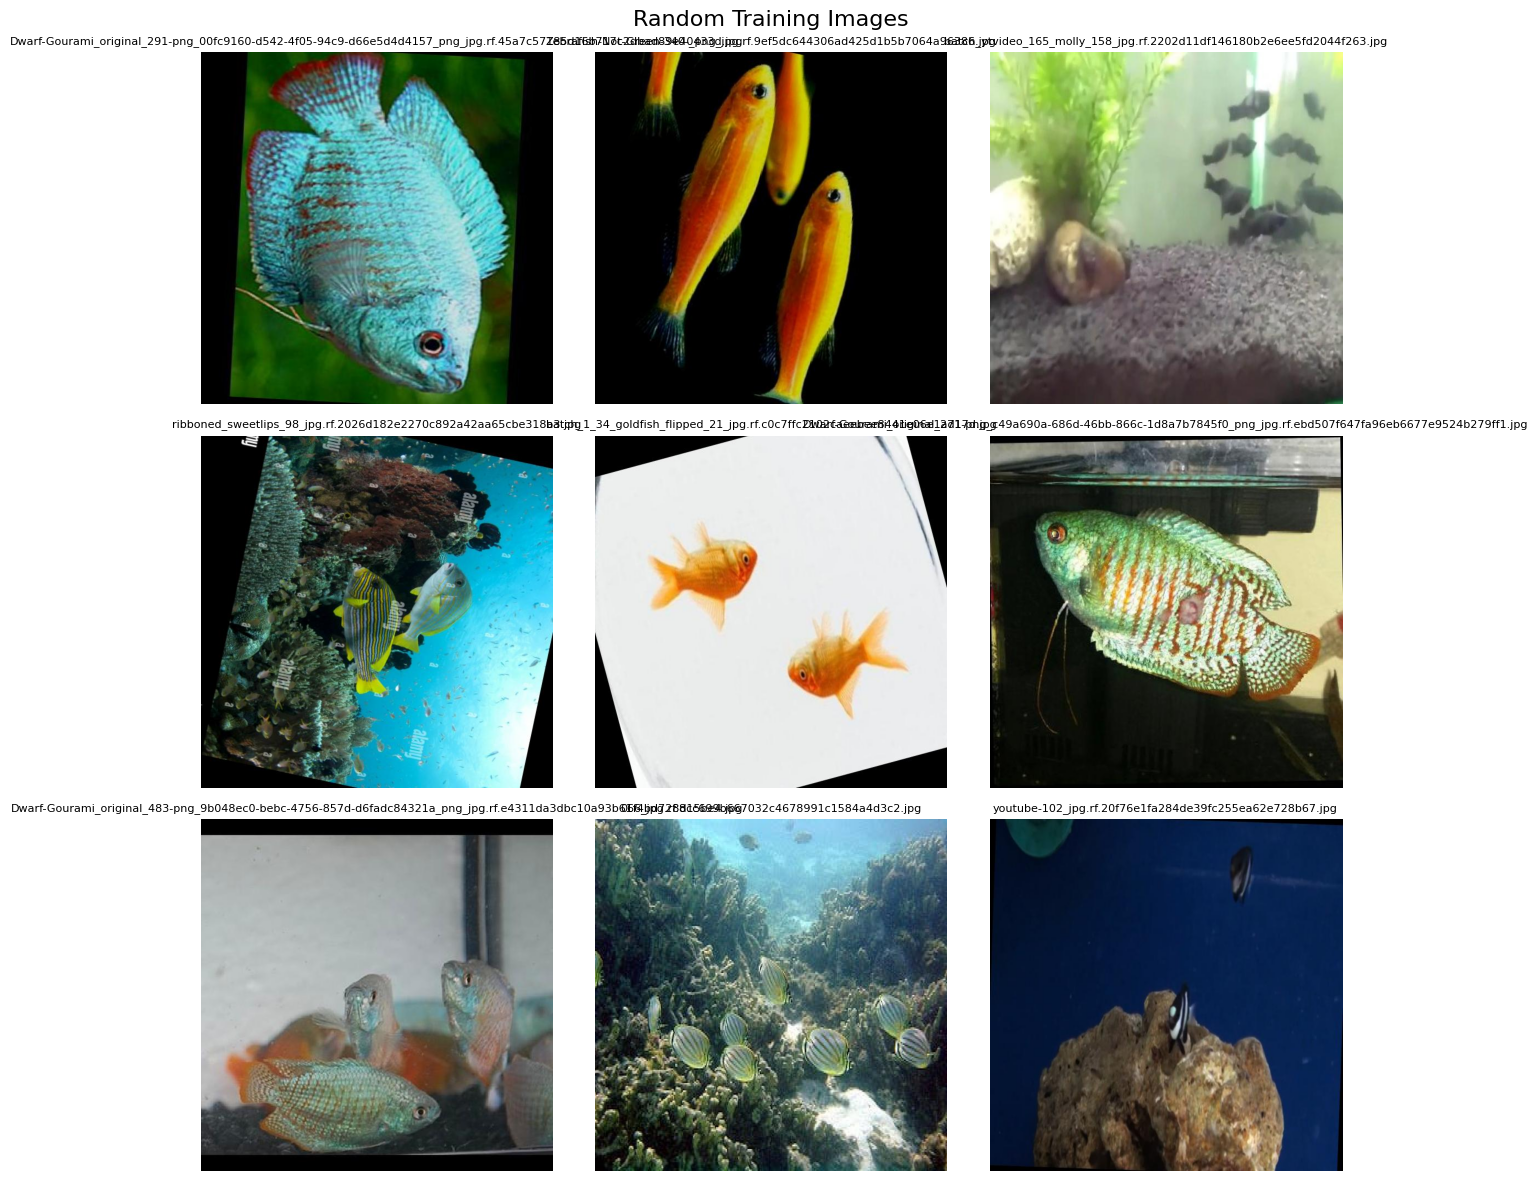

In [ ]:
# Quick Sanity Check (Random Images)
import random
import matplotlib.pyplot as plt
from PIL import Image

image_files = list((LOCAL_DATASET / "train" / "images").glob("*.jpg"))

samples = random.sample(image_files, 9)

plt.figure(figsize=(12,12))

for i, img_path in enumerate(samples):

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.suptitle("Random Training Images", fontsize=16)

plt.tight_layout()

plt.show()

In [ ]:
# YOLOv8 Training phase

DATA_YAML = LOCAL_DATASET / "data.yaml"

MODEL = "yolov8s.pt"
EPOCHS = 60
IMAGE_SIZE = 640
BATCH_SIZE = 32
PATIENCE = 15
RUN_NAME = "fish_yolov8s_colab"
RUNS_DIR = Path("/content/runs")

model = YOLO(MODEL)

print("Starting training...")
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=0,
    workers=2,             # Colab gives ~2 CPU cores; more than this doesn't help and can stall the loader
    patience=PATIENCE,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    cache=False,           # dataset's already on local SSD, so caching to RAM buys little and risks OOM on 12GB RAM
    seed=42,
    deterministic=True,
    verbose=True,
    plots=True,
    save_period=5,         # checkpoint every 5 epochs, in case the session drops
    amp=True               # mixed precision — meaningful speedup on T4's tensor cores
)

run_dir = Path(results.save_dir)
print("Training complete. Run saved at:", run_dir)

In [ ]:
## model

model = YOLO(str(RUNS_DIR / RUN_NAME / "weights" / "last.pt"))
results = model.train(resume=True)

In [ ]:
# saving Model, Plots, CSVs to Drive

import pandas as pd
import matplotlib.pyplot as plt

PERSIST_DIR = OUTPUT_DIR / "training" / RUN_NAME
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Copying full run folder to Drive (weights + logs)...")
if PERSIST_DIR.exists():
    shutil.rmtree(PERSIST_DIR)
shutil.copytree(run_dir, PERSIST_DIR)
print("Copied to:", PERSIST_DIR)

# results.csv to clean curves
results_csv = run_dir / "results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
df.to_csv(OUTPUT_DIR / "training_results.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0,0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0,0].set_title("Box Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[0,1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[0,1].set_title("Classification Loss"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[1,0].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[1,0].plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
axes[1,0].set_title("Precision & Recall"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

axes[1,1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[1,1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1,1].set_title("mAP"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=300)
plt.show()

# best weight open and save
best_weights_drive = PERSIST_DIR / "weights" / "best.pt"
with open(OUTPUT_DIR / "best_weights_path.txt", "w") as f:
    f.write(str(best_weights_drive))

print("Best weights saved at:", best_weights_drive)
print("Everything is safely in Drive under:", OUTPUT_DIR)

# ---- Optional: download best.pt straight to your laptop ----
# from google.colab import files
# files.download(str(best_weights_drive))

In [ ]:
!cat "/content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab/args.yaml"

In [ ]:
from pathlib import Path
print(Path("/content/runs/fish_yolov8s_colab/weights/best.pt").exists())

In [ ]:
import shutil
from pathlib import Path

RUNS_DIR = Path("/content/runs")
CORRECT_RUN = RUNS_DIR / "fish_yolov8s_colab"
OUTPUT_DIR = Path("/content/drive/MyDrive/FishProjectOutputs")

PERSIST_DIR = OUTPUT_DIR / "training" / "fish_yolov8s_colab"
if PERSIST_DIR.exists():
    shutil.rmtree(PERSIST_DIR)
shutil.copytree(CORRECT_RUN, PERSIST_DIR)

best_weights_drive = PERSIST_DIR / "weights" / "best.pt"
with open(OUTPUT_DIR / "best_weights_path.txt", "w") as f:
    f.write(str(best_weights_drive))

print("Fixed. Weights now at:", best_weights_drive)

In [ ]:

#Model Evaluation Test Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

EVAL_DIR = OUTPUT_DIR / "evaluation"
FIG_DIR = OUTPUT_DIR / "figures"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish', 'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

with open(OUTPUT_DIR / "best_weights_path.txt") as f:
    WEIGHTS_PATH = f.read().strip()

print("Loading weights from:", WEIGHTS_PATH)
model = YOLO(WEIGHTS_PATH)


# validation on the TEST split
metrics = model.val(
    data=str(LOCAL_DATASET / "data.yaml"),
    split="test",
    conf=0.25,
    iou=0.5,
    save_json=True,
    plots=True,
    project=str(EVAL_DIR),
    name="test_eval"
)

# Per-class precision / recall / mAP / F1
per_class = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": metrics.box.p,
    "Recall": metrics.box.r,
    "mAP50": metrics.box.ap50,
    "mAP50-95": metrics.box.ap,
    "F1": metrics.box.f1
})
per_class.to_csv(EVAL_DIR / "per_class_metrics.csv", index=False)
print(per_class)

overall = {
    "Precision(mean)": metrics.box.mp,
    "Recall(mean)": metrics.box.mr,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
}
pd.Series(overall).to_csv(EVAL_DIR / "overall_metrics.csv")
print(overall)

# confusion matrix
cm = metrics.confusion_matrix.matrix
labels = CLASS_NAMES + ["background"]

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(EVAL_DIR / "confusion_matrix_raw.csv")

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=300)
plt.show()

# TP / FP / FN per class
nc = len(CLASS_NAMES)
tp = np.diag(cm)[:nc]
fp = cm[:nc, :].sum(axis=1) - tp
fn = cm[:, :nc].sum(axis=0) - tp

tpfpfn = pd.DataFrame({"Class": CLASS_NAMES, "TP": tp, "FP": fp, "FN": fn})
tpfpfn.to_csv(EVAL_DIR / "tp_fp_fn_per_class.csv", index=False)
print(tpfpfn)

print("\nEvaluation complete. Everything saved under:", EVAL_DIR)

In [ ]:
# fish Count with each img inference
from pathlib import Path
import pandas as pd
from ultralytics import YOLO

COUNT_DIR = OUTPUT_DIR / "counting"
COUNT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish',
               'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
               'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

with open(OUTPUT_DIR / "best_weights_path.txt") as f:
    WEIGHTS_PATH = f.read().strip()

model = YOLO(WEIGHTS_PATH)

TEST_IMG_DIR = LOCAL_DATASET / "test" / "images"
CONF_THRESHOLD = 0.25

per_image_rows = []
detection_records = []

# save
results = model.predict(
    source=str(TEST_IMG_DIR),
    conf=CONF_THRESHOLD,
    save=True,
    project=str(COUNT_DIR),
    name="predictions",
    verbose=False
)

for r in results:
    img_name = Path(r.path).name

    if r.boxes is not None and len(r.boxes) > 0:
        class_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
    else:
        class_ids, confs = [], []

    counts = {name: 0 for name in CLASS_NAMES}
    for cid in class_ids:
        counts[CLASS_NAMES[cid]] += 1

    row = {"Image": img_name, "Total_Fish": len(class_ids)}
    row.update(counts)
    per_image_rows.append(row)

    for cid, conf in zip(class_ids, confs):
        detection_records.append({
            "Image": img_name,
            "Species": CLASS_NAMES[cid],
            "Confidence": float(conf)
        })

per_image_df = pd.DataFrame(per_image_rows)
per_image_df.to_csv(COUNT_DIR / "fish_counts_per_image.csv", index=False)

detections_df = pd.DataFrame(detection_records)
detections_df.to_csv(COUNT_DIR / "all_detections.csv", index=False)

species_totals = (
    detections_df["Species"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    .reset_index()
)
species_totals.columns = ["Species", "Total_Count"]
species_totals.to_csv(COUNT_DIR / "species_totals.csv", index=False)

print(per_image_df.head())
print(species_totals)
print(f"\nTotal images processed: {len(per_image_df)}")
print(f"Total fish detected: {detections_df.shape[0]}")
print("Fish counting complete. Annotated images saved in:", COUNT_DIR / "predictions")

In [ ]:

# have to run if Server is disconnected

!pip install -q ultralytics seaborn opencv-python-headless

import os, shutil, yaml
from pathlib import Path
import torch
from ultralytics import YOLO

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATASET = Path("/content/drive/MyDrive/FishDetection.v5i.yolov11")
LOCAL_DATASET = Path("/content/FishDetection.v5i.yolov11")
OUTPUT_DIR = Path("/content/drive/MyDrive/FishProjectOutputs")
OUTPUT_DIR.mkdir(exist_ok=True)


LOCAL_DATASET.mkdir(parents=True, exist_ok=True)
for split in ["valid", "test"]:
    dst = LOCAL_DATASET / split
    if dst.exists():
        shutil.rmtree(dst)
    print(f"Copying {split} split...")
    shutil.copytree(DRIVE_DATASET / split, dst)
print("Done — valid + test copied locally (train skipped).")

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish',
               'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
               'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

# Trimmed data.yaml — 'train' key points at valid/ as a placeholder since
# we never call model.train() again; only val()/predict() run from here.
data_yaml = {
    "path": str(LOCAL_DATASET),
    "train": "valid/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}
with open(LOCAL_DATASET / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

with open(OUTPUT_DIR / "best_weights_path.txt") as f:
    WEIGHTS_PATH = f.read().strip()

model = YOLO(WEIGHTS_PATH)
print("Model loaded from:", WEIGHTS_PATH)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — check Runtime settings")

In [ ]:
# ccommunity Composition Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COMM_DIR = OUTPUT_DIR / "community"
FIG_DIR = OUTPUT_DIR / "figures"
COMM_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

counts_path = OUTPUT_DIR / "counting" / "species_totals.csv"
species_totals = pd.read_csv(counts_path)

# Abundance & relative abundance
total_individuals = species_totals["Total_Count"].sum()
species_totals["Relative_Abundance_%"] = (
    species_totals["Total_Count"] / total_individuals * 100
).round(2)

species_totals = species_totals.sort_values("Total_Count", ascending=False).reset_index(drop=True)
species_totals["Rank"] = species_totals.index + 1
species_totals.to_csv(COMM_DIR / "abundance_table.csv", index=False)
print(species_totals)

# present = species actually detected (excludes ButterflyFish, likely 0)
present = species_totals[species_totals["Total_Count"] > 0]
dominant_species = present.iloc[0]["Species"]
rarest_species = present.iloc[-1]["Species"]

# Diversity indices
p = present["Total_Count"] / total_individuals
shannon_index = -np.sum(p * np.log(p))
simpson_index = 1 - np.sum(p ** 2)
species_richness = present.shape[0]
pielou_evenness = shannon_index / np.log(species_richness) if species_richness > 1 else np.nan

diversity_summary = pd.DataFrame({
    "Metric": ["Total Individuals Detected", "Species Richness (detected)",
               "Shannon Index (H')", "Simpson Index (1-D)", "Pielou Evenness (J')",
               "Dominant Species", "Rarest Detected Species"],
    "Value": [total_individuals, species_richness,
              round(shannon_index, 3), round(simpson_index, 3),
              round(pielou_evenness, 3) if pd.notna(pielou_evenness) else "n/a",
              dominant_species, rarest_species]
})
diversity_summary.to_csv(COMM_DIR / "diversity_indices.csv", index=False)
print(diversity_summary)

# Figures
plt.figure(figsize=(12, 6))
plt.bar(species_totals["Species"], species_totals["Total_Count"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Abundance (individuals detected)")
plt.title("Species Abundance - Test Set Detections")
plt.tight_layout()
plt.savefig(FIG_DIR / "community_abundance.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 9))
colors = plt.cm.tab20.colors[:len(present)]
wedges, _ = plt.pie(present["Total_Count"], startangle=90, colors=colors)
plt.legend(
    wedges,
    [f"{sp} ({pct}%)" for sp, pct in zip(present["Species"], present["Relative_Abundance_%"])],
    title="Species",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Relative Abundance by Species")
plt.tight_layout()
plt.savefig(FIG_DIR / "community_relative_abundance.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(present["Rank"], present["Total_Count"], marker="o")
plt.yscale("log")
plt.xlabel("Species Rank")
plt.ylabel("Abundance (log scale)")
plt.title("Rank-Abundance Curve")
plt.tight_layout()
plt.savefig(FIG_DIR / "rank_abundance_curve.png", dpi=300)
plt.show()

print("Community composition analysis complete.")

In [ ]:
print("Model loaded from:", WEIGHTS_PATH)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — check Runtime settings")

In [ ]:

# confidence Threshold Analysis

import pandas as pd
import matplotlib.pyplot as plt

THRESH_DIR = OUTPUT_DIR / "threshold_analysis"
FIG_DIR = OUTPUT_DIR / "figures"
THRESH_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLDS = [0.25, 0.50, 0.75]
rows = []

for conf in THRESHOLDS:
    print(f"\nRunning validation at conf={conf} ...")
    metrics = model.val(
        data=str(LOCAL_DATASET / "data.yaml"),
        split="test",
        conf=conf,
        iou=0.5,
        plots=False,
        project=str(THRESH_DIR),
        name=f"conf_{conf}"
    )

    cm = metrics.confusion_matrix.matrix
    nc = cm.shape[0] - 1
    tp = cm.diagonal()[:nc].sum()
    fp = cm[:nc, :].sum() - tp
    fn = cm[:, :nc].sum() - tp

    rows.append({
        "Confidence_Threshold": conf,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "TP": tp, "FP": fp, "FN": fn
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(THRESH_DIR / "threshold_comparison.csv", index=False)
print(threshold_df)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["Precision"], marker="o", label="Precision")
axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["Recall"], marker="o", label="Recall")
axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["mAP50"], marker="o", label="mAP50")
axes[0].set_xlabel("Confidence Threshold")
axes[0].set_title("Precision / Recall / mAP vs Confidence Threshold")
axes[0].legend()

width = 0.03
x = threshold_df["Confidence_Threshold"]
axes[1].bar(x - width, threshold_df["TP"], width=width, label="TP")
axes[1].bar(x, threshold_df["FP"], width=width, label="FP")
axes[1].bar(x + width, threshold_df["FN"], width=width, label="FN")
axes[1].set_xlabel("Confidence Threshold")
axes[1].set_title("TP / FP / FN vs Confidence Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "confidence_threshold_analysis.png", dpi=300)
plt.show()


In [ ]:
print(threshold_df)

In [ ]:
# Total ground-truth instances in test set
total_instances = sum(
    len(open(f).read().strip().splitlines())
    for f in (LOCAL_DATASET / "test" / "labels").glob("*.txt")
)
print("Total ground-truth instances in test set:", total_instances)

fixed_rows = []
for row in rows:
    precision = row["Precision"]
    recall = row["Recall"]

    tp = round(recall * total_instances)
    fn = total_instances - tp
    fp = round(tp * (1 - precision) / precision) if precision > 0 else 0

    fixed_rows.append({**row, "TP": tp, "FP": fp, "FN": fn})

threshold_df = pd.DataFrame(fixed_rows)
threshold_df.to_csv(THRESH_DIR / "threshold_comparison.csv", index=False)
print(threshold_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["Precision"], marker="o", label="Precision")
axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["Recall"], marker="o", label="Recall")
axes[0].plot(threshold_df["Confidence_Threshold"], threshold_df["mAP50"], marker="o", label="mAP50")
axes[0].set_xlabel("Confidence Threshold")
axes[0].set_title("Precision / Recall / mAP vs Confidence Threshold")
axes[0].legend()

width = 0.03
x = threshold_df["Confidence_Threshold"]
axes[1].bar(x - width, threshold_df["TP"], width=width, label="TP")
axes[1].bar(x, threshold_df["FP"], width=width, label="FP")
axes[1].bar(x + width, threshold_df["FN"], width=width, label="FN")
axes[1].set_xlabel("Confidence Threshold")
axes[1].set_title("TP / FP / FN vs Confidence Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "confidence_threshold_analysis.png", dpi=300)
plt.show()

In [ ]:

# error analysis and conclusion

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

ERR_DIR = OUTPUT_DIR / "error_analysis"
FIG_DIR = OUTPUT_DIR / "figures"
EXAMPLES_DIR = ERR_DIR / "examples"
ERR_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish',
               'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
               'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

TEST_IMG_DIR = LOCAL_DATASET / "test" / "images"
TEST_LBL_DIR = LOCAL_DATASET / "test" / "labels"
CONF_THRESHOLD = 0.25
IOU_MATCH_THRESHOLD = 0.5
SMALL_BOX_AREA = 0.01
MAX_SAVED_CROPS = 30


def yolo_to_xyxy(x, y, w, h):
    return x - w / 2, y - h / 2, x + w / 2, y + h / 2


def iou(box1, box2):
    xa1, ya1, xa2, ya2 = box1
    xb1, yb1, xb2, yb2 = box2
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0


fp_records, fn_records = [], []
n_fp_saved, n_fn_saved = 0, 0

image_paths = sorted(TEST_IMG_DIR.glob("*.*"))
print(f"Processing {len(image_paths)} test images...")

for idx, img_path in enumerate(image_paths):
    if idx % 100 == 0:
        print(f"  {idx}/{len(image_paths)}")

    label_path = TEST_LBL_DIR / f"{img_path.stem}.txt"
    gt_boxes = []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cid = int(float(p[0]))
            x, y, w, h = map(float, p[1:])
            gt_boxes.append({"cls": cid, "box": yolo_to_xyxy(x, y, w, h), "area": w * h})

    result = model.predict(source=str(img_path), conf=CONF_THRESHOLD, verbose=False)[0]
    pred_boxes = []
    if result.boxes is not None and len(result.boxes) > 0:
        for box, cid, conf in zip(result.boxes.xyxyn.cpu().numpy(),
                                   result.boxes.cls.cpu().numpy().astype(int),
                                   result.boxes.conf.cpu().numpy()):
            pred_boxes.append({"cls": cid, "box": tuple(box), "conf": float(conf)})

    matched_gt, matched_pred = set(), set()

    for pi, pred in enumerate(pred_boxes):
        best_iou, best_gi = 0, -1
        for gi, gt in enumerate(gt_boxes):
            if gi in matched_gt or gt["cls"] != pred["cls"]:
                continue
            cur_iou = iou(pred["box"], gt["box"])
            if cur_iou > best_iou:
                best_iou, best_gi = cur_iou, gi
        if best_iou >= IOU_MATCH_THRESHOLD:
            matched_gt.add(best_gi)
            matched_pred.add(pi)

    for pi, pred in enumerate(pred_boxes):
        if pi not in matched_pred:
            fp_records.append({
                "Image": img_path.name,
                "Predicted_Class": CLASS_NAMES[pred["cls"]],
                "Confidence": pred["conf"]
            })
            if n_fp_saved < MAX_SAVED_CROPS:
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                    x1, y1, x2, y2 = pred["box"]
                    cv2.rectangle(img, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0, 0, 255), 2)
                    cv2.imwrite(str(EXAMPLES_DIR / f"FP_{img_path.stem}_{pi}.jpg"), img)
                    n_fp_saved += 1

    for gi, gt in enumerate(gt_boxes):
        if gi not in matched_gt:
            size_cat = "small" if gt["area"] < SMALL_BOX_AREA else "normal"
            fn_records.append({
                "Image": img_path.name,
                "True_Class": CLASS_NAMES[gt["cls"]],
                "Box_Area": gt["area"],
                "Size_Category": size_cat
            })
            if n_fn_saved < MAX_SAVED_CROPS:
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                    x1, y1, x2, y2 = gt["box"]
                    cv2.rectangle(img, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0, 255, 255), 2)
                    cv2.imwrite(str(EXAMPLES_DIR / f"FN_{img_path.stem}_{gi}.jpg"), img)
                    n_fn_saved += 1

print("Done processing all images.")

fp_df = pd.DataFrame(fp_records)
fn_df = pd.DataFrame(fn_records)
fp_df.to_csv(ERR_DIR / "false_positives.csv", index=False)
fn_df.to_csv(ERR_DIR / "false_negatives.csv", index=False)

fn_by_size = fn_df["Size_Category"].value_counts()
fn_by_size.to_csv(ERR_DIR / "fn_by_size_category.csv")

fp_by_class = fp_df["Predicted_Class"].value_counts()
fn_by_class = fn_df["True_Class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fp_by_class.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("False Positives by Predicted Class")
fn_by_class.plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("False Negatives by True Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "error_by_class.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
fn_by_size.plot(kind="bar", color="darkred")
plt.title("False Negatives by Object Size (small vs normal)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fn_by_size.png", dpi=300)
plt.show()

print(f"\nFalse Positives: {len(fp_df)}")
print(f"False Negatives: {len(fn_df)}")
print(fn_by_size)
print(f"\nExample crops saved to Drive under: {EXAMPLES_DIR}")

In [ ]:
import cv2
from pathlib import Path

TARGET_DIR = ERR_DIR / "targeted_examples"
TARGET_DIR.mkdir(parents=True, exist_ok=True)

TARGET_IMAGES = [
    "10_jpeg.rf.94951c0379fe621911e4e48a35dc44e1.jpg",                        # ThreeStripedDamselfish FP
    "youtube-6_jpg.rf.7e421467cb6339bcca3db533d8cf1b4a.jpg",                  # ThreeStripedDamselfish FP (3 boxes)
    "IMG_3120_jpg.rf.e33238bd987037cd59f664e5f1d2599e.jpg",                   # YellowCichlid schooling
    "IMG_3127_jpg.rf.44cd058c00c2cb18967ec2e85d1dfacb.jpg",                   # YellowCichlid schooling
    "batch_ytvideo_165_molly_69_jpg.rf.eeef6396de5e3393de627e10cb359066.jpg", # PlatyFish heavy FP
]

for fname in TARGET_IMAGES:
    img_path = TEST_IMG_DIR / fname
    if not img_path.exists():
        print("MISSING:", fname)
        continue

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    label_path = TEST_LBL_DIR / f"{img_path.stem}.txt"
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cid = int(float(p[0]))
            x, y, bw, bh = map(float, p[1:])
            x1, y1, x2, y2 = yolo_to_xyxy(x, y, bw, bh)
            cv2.rectangle(img, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0, 255, 255), 2)
            cv2.putText(img, f"GT:{CLASS_NAMES[cid]}", (int(x1*w), int(y1*h)-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

    result = model.predict(source=str(img_path), conf=CONF_THRESHOLD, verbose=False)[0]
    if result.boxes is not None:
        for box, cid, conf in zip(result.boxes.xyxyn.cpu().numpy(),
                                   result.boxes.cls.cpu().numpy().astype(int),
                                   result.boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = box
            cv2.rectangle(img, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0, 0, 255), 2)
            cv2.putText(img, f"Pred:{CLASS_NAMES[cid]} {conf:.2f}", (int(x1*w), int(y2*h)+15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    out_path = TARGET_DIR / f"annotated_{img_path.stem}.jpg"
    cv2.imwrite(str(out_path), img)
    print("Saved:", out_path.name)

print("\nAll saved to:", TARGET_DIR)